<a href="https://colab.research.google.com/github/nikamade/Data201/blob/main/MADINKOEPSEKAMGUI_Project1_Week8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **PROJECT1**: **An Analysis of OCA Code Enforcement Citations in Montgomery County**

# **Monique Madinko Epse Kamgui**
# **April 1, 2026**



## ** Import Libraries and Upload the Dataset**

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
df = pd.read_csv("https://raw.githubusercontent.com/nikamade/Data201_MoniqueMadinkoEpseKamgui/refs/heads/main/OCA_Code_Enforcement_-_API_20260331.csv", low_memory=False)


# Introduction
This project analyzes the OCA Code Enforcement dataset, which compiles civil citations issued by Montgomery County, Maryland. The OCA, defined as the Office of the County Attorney, is responsible for legal enforcement and ensuring compliance with local codes. This study focuses on property owners, business owners, and residents in Montgomery County who have received a citation for non-compliance with county laws. These infractions cover a wide range of areas, including housing, fire safety, zoning, environmental protection, transportation, health, animal services, and many others. This dataset is sourced from the Montgomery County Open Data Portal; it is titled "OCA Code Enforcement," and the information was gathered during inspections conducted by these various departments. Regarding potential biases, one may note undetected infractions for instance, when an inspector finds everything in order during a business visit because the company had prepared in advance or unreported infractions, such as when one town shows more citations than another simply because its residents report issues more frequently, perhaps due to a lack of neighborly harmony.

**Source**: Montgomery County Government. 2026. OCA Code Enforcement Citations.https://data.montgomerycountymd.gov/Law-Judicial/OCA-Code-Enforcement-API/stub-73vh/data_preview.

I also downlod it in my github before upload it in google collab here is the link https://raw.githubusercontent.com/nikamade/Data201_MoniqueMadinkoEpseKamgui/refs/heads/main/OCA_Code_Enforcement_-_API_20260331.csv


## **Data Structure**

Te dataset has 10 variables total but i will work with these 4 variables:

| Nom de la Variable | Description | Type |
| :--- | :--- | :--- |
| **Department** | Service municipal responsable. | Catégorielle |
| **Violation Code** | Code de loi enfreint. | Catégorielle |
| **Citation Amount** | Montant de l'amende ($). | Quantitative |
| **Open Date** | Date d'enregistrement. | Quantitative |

# **Data Exploration**

In [2]:
df.info()  # show info about the entire dataset  total and typ

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1023489 entries, 0 to 1023488
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Citation No       12559 non-null  object
 1   Department        12559 non-null  object
 2   Status            12559 non-null  object
 3   Open Date         12559 non-null  object
 4   Citation Date     12552 non-null  object
 5   Status Date       12559 non-null  object
 6   Citation Amount   12527 non-null  object
 7   Disposition Code  3425 non-null   object
 8   Disposition Date  3350 non-null   object
 9   Violation Code    12559 non-null  object
dtypes: object(10)
memory usage: 78.1+ MB


After using de info() function, I notice thet we have 12559 raws total while the range idex shows 1023489 entries meanning thet the dataset has a lot of empty raws. i will remove those space in the next step and show objet to numerical variable

In [3]:
df.dropna(how='all')

,Citation No,Department,Status,Open Date,Citation Date,Status Date,Citation Amount,Disposition Code,Disposition Date,Violation Code
0,3Z47121399,Washington Metro. and Transit Auth. Police,Open,03/26/2025,03/11/2025,03/26/2025,50.00,NaN,NaN,54-A-2-9
1,3Z36236385,Department of Housing and Community Affairs,Open,12/06/2023,11/09/2023,12/06/2023,500.00,Continued,02/25/2025,26-9(a)(1)
2,3Z36240039,Department of Housing and Community Affairs,Open,03/27/2025,03/20/2025,03/27/2025,500.00,NaN,NaN,26-9(a)(2)
3,6Z42259573,Health and Human Services,Open,08/30/2020,08/01/2020,08/30/2020,500.00,Abatement Order entered,12/16/2020,1-18-a-2
4,2Z47055353,Health and Human Services,Open,10/17/2024,10/09/2024,10/17/2024,"1,000.00",NaN,NaN,24-11-B(1)(i)
...,...,...,...,...,...,...,...,...,...,...
1023484,3Z42321695,Department of Permitting Services,Open,01/15/2026,10/30/2025,01/15/2026,500.00,NaN,NaN,12-22-22
1023485,3z42321394,Department of Permitting Services,Open,12/06/2024,12/02/2024,12/06/2024,NaN,NaN,NaN,24-a-6-a-1
1023486,5Z42320311,Department of Permitting Services,Closed,08/27/2021,08/23/2021,02/11/2026,500.00,Show Cause Order Withdrawn,02/20/2024,59-6-2-5-L
1023487,6Z36217803,Department of Housing and Community Affairs,Closed,03/13/2017,03/08/2017,03/01/2026,500.00,Abatement Order entered,07/25/2017,26-8(a)(1)


# **Data Analyses**

## **Quantitative variable (Descriptive)**

**My Question:** What is the most frequent code violation fine in Montgomery County?


* **Data Cleanning**

In [4]:
df_clean =df.dropna(subset=['Citation Amount']) # removing na in citation amount
df_clean['Citation Amount'] = pd.to_numeric(df_clean['Citation Amount'], errors='coerce') #convert to numrical value
df_clean['Citation Amount'].dtype

/tmp/ipykernel_4067/3864884611.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clean['Citation Amount'] = pd.to_numeric(df_clean['Citation Amount'], errors='coerce') #convert to numrical value


dtype('float64')

* **Summary Stat**

In [5]:
stats = df_clean['Citation Amount'].describe()
print (stats)
print (f"Median: {df_clean['Citation Amount'].median()}")

count    10508.000000
mean       371.808146
std        201.370269
min          0.000000
25%        100.000000
50%        500.000000
75%        500.000000
max        750.000000
Name: Citation Amount, dtype: float64
Median: 500.0


The column Citation Amount is quantitative variable. It is appropriate for this analysis because it represents a numerical value.

* **Visualization: Histogram**

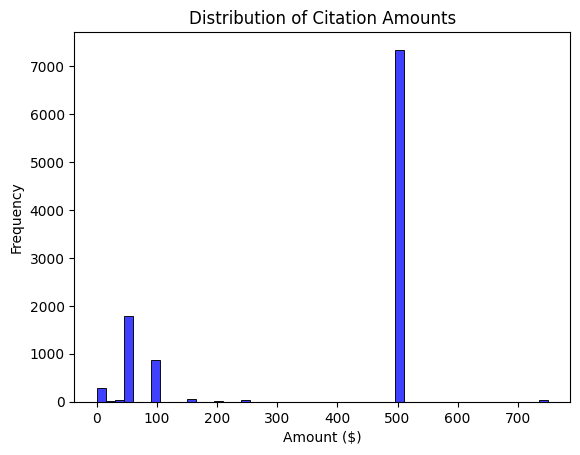

In [35]:
sns.histplot( data = df_clean, x='Citation Amount', bins=50, color='blue')
plt.title('Distribution of Citation Amounts')
plt.xlabel('Amount ($)')
plt.ylabel('Frequency')
plt.show()

# **Discussion**

* **Data Cleaning & Transformation**: In this dataset, I converted the column Citation Amount to a float type because it was read at a string. i use the function pd.to numeric then removed missing entries with the function  (dropna) to ensure accurate calculations..

* **Measures of Center and Spread**: There is a significant difference between the mean ($371.81) and the median ($500.00). meanning there are people who pay less while others pay high

**Outliers**: Statistically, there are no extreme high-value outliers, as the maximum fine ($750) is close to the median.  

**Shape of Distribution**: The distribution is Left-Skewed. This is confirmed numerically because the Mean < Median. Visually, the histogram shows a massive "peak" on the right at $500.

# **Categorical Variable (Descriptive)**



In [7]:
print(df_clean['Department'].unique())

['Washington Metro. and Transit Auth. Police'
 'Department of Housing and Community Affairs' 'Health and Human Services'
 'Department of Permitting Services' 'Office of Animal Services'
 'Office of Consumer Protection' 'Department of Environmental Protection'
 'False Alarm' 'Animal Control and Humane Treatment'
 'Department of Environmental Protection/Solid Waste'
 'Department of Transportation' 'Police Department' 'Taxicab'
 'Washington Metro. Area Transit Auth.' 'Animal Matters Hearing Board']


* **My Question**: "Which specific department are responsible for issuing civil citations?

It is appropriate because the variable is Variable  Qualitative or Categorical
 with 15 different departments.

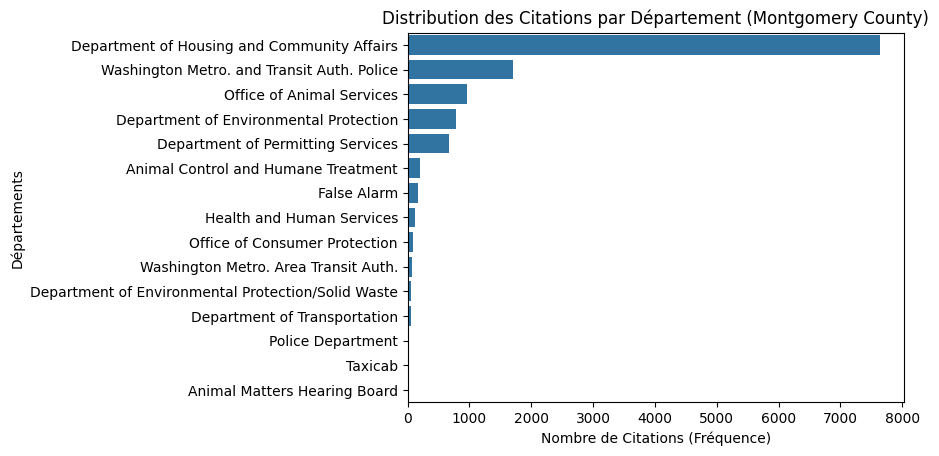

In [8]:
sns.countplot(data=df_clean,
              y='Department',
              order=df_clean['Department'].value_counts().index,)

plt.title('Distribution des Citations par Département (Montgomery County)')
plt.xlabel('Nombre de Citations (Fréquence)')
plt.ylabel('Départements')
plt.show()

* **Summary Statistics **

Measure of Center: The Mode is Department of Housing and Community Affairs Department

# **Discussion**

Data cleaning or transformation
Definition of levels
Interpretation of results

My data were clean no missing values

* **Visualization**
the graph show that the Department of Housing and Community Affairs is the one who handles the vast majority of enforcement.

# **Correlation**: Times Vs Amount

Coefficient de corrélation (r) : -0.225


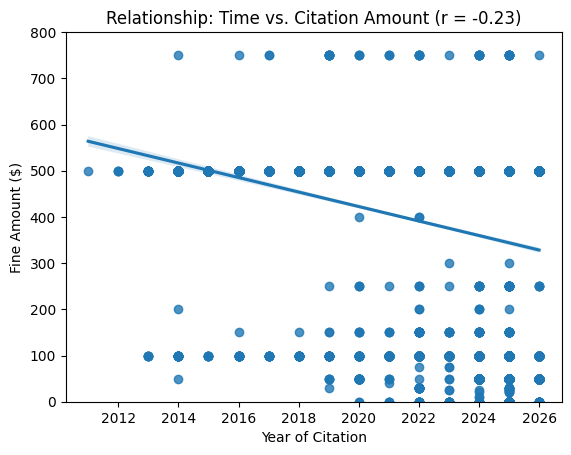

In [34]:
df_clean['Citation Date'] = pd.to_datetime(df_clean['Citation Date'], errors='coerce') #convert to date time
df_clean['Year'] = df_clean['Citation Date'].dt.year
df_clean = df_clean[(df_clean['Year'] >= 2010) & (df_clean['Year'] <= 2026)] # extract hear between 2010 & 2026)

correlation = df_clean['Year'].corr(df_clean['Citation Amount'])
print(f"Coefficient de corrélation (r) : {correlation:.3f}")


# regplot for thee scatterplot + and line de tendance rouge
sns.regplot(data=df_clean, x='Year', y='Citation Amount') #,
            #scatter_kws={'alpha':0.2, 'color':'gray'},
            #line_kws={'color':'red'})
plt.ylim(0, 800)
plt.title(f'Relationship: Time vs. Citation Amount (r = {correlation:.2f})')
plt.xlabel('Year of Citation')
plt.ylabel('Fine Amount ($)')
plt.show()

**Explanation**

In terms of correlation, I think there could be a positive correlation in the sense that this is a study that spans several years, and as time goes on, life becomes more expensive. So, due to the cost of living and inflation, we would expect that as time passes, prices increase. However, in terms of a negative correlation, I did not initially expect it, but after calculating the correlation and visualizing the data, I noticed that the correlation was actually slightly negative: as time passes, the amount of fines tends to decrease. This correlation is weak (around -0.225), meaning it exists but is not strong. This can be explained by the fact that, due to a lot of missing payments, authorities decide to adjust policies to encourage people to pay their fines. The weakness of this correlation suggests that time has some influence on the amount of fines, but it is not the main determining factor; other variables likely have a stronger impact.

# **Nonparametric Inference (Median)**
**Results of the inference**

* **Median**: $502.00

* **Standar Error**: 0.00

* **Bootstrap Statistics**: 1,000 Iterations

* **Mean of Bootstrap Medians**: $502.00

* **Confidence Interval**: [$502.00, $502.00]

The nonparametric inference(Boostrap) provides strong evidence for the central tendency of the dataset
The median is 502 and the CI are also 502.00 with ST of 0.00 meanning the most citation amount is tehat 502 . so i can state that  I am 95% confident true median citation amount for the entire population of Montgomery County falls between $502.00 and $502.00."



Sample median: 5e+02
Sample Std: 2e+02


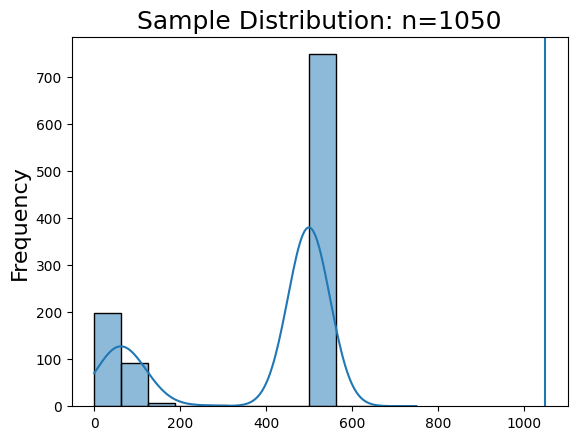

In [24]:
df_clean = df_clean.dropna(subset=['Citation Amount'])
population_n = len(df_clean)
sample_size = int(population_n * 0.10)

# 2. On tire l'échantillon de départ (Une seule fois !)
np.random.seed(42)
initial_sample = np.random.choice(df_clean['Citation Amount'], size=sample_size, replace=False)
sns.histplot(initial_sample, kde=True, label='Single Sample')
plt.axvline(x=np.median(sample_size), ymin=0, ymax=1, linestyle='-')
plt.title(f'Sample Distribution: n={sample_size}', fontsize=18)
plt.ylabel('Frequency', fontsize=16)

print(f'Sample median: {np.median(initial_sample):.2}')
print(f'Sample Std: {np.std(initial_sample):.2}')



Bootstrapped median: 5e+02
Bootstrapped Std: 0.0


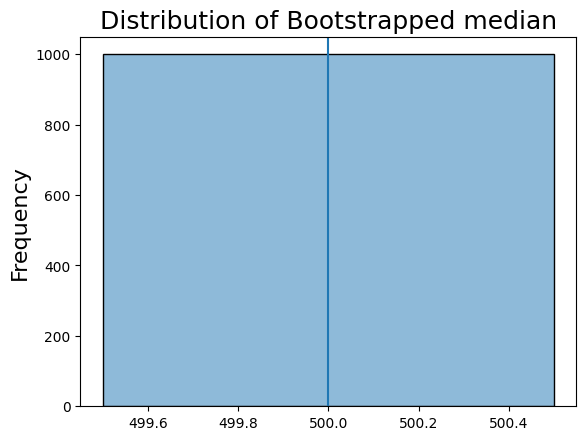

In [27]:
df_clean = df_clean.dropna(subset=['Citation Amount'])
population_n = len(df_clean)
sample_size = int(population_n * 0.10)

# 2. On tire l'échantillon de départ (Une seule fois !)
np.random.seed(42)
initial_sample = np.random.choice(df_clean['Citation Amount'], size=sample_size, replace=False)
n_bootstrap = 1000

bootstrap_median = []
for b in range(n_bootstrap):
    bootstrap_median.append(np.median(np.random.choice(initial_sample, size=sample_size, replace=True)))
bootstrap_median = np.array(bootstrap_median)

sns.histplot(bootstrap_median, kde=True, label='Bootstrap')
plt.axvline(x=np.median(bootstrap_median), ymin=0, ymax=1, linestyle='-')
plt.title('Distribution of Bootstrapped median', fontsize=18)
plt.ylabel('Frequency', fontsize=16)

print(f'Bootstrapped median: {np.median(bootstrap_median):.3}')
print(f'Bootstrapped Std: {np.std(bootstrap_median):.3}')

because the inteval is the same as a median one line is represented

Bootstrapped median: 5e+02
95% Confidence Intervals: [5e+02, 5e+02]


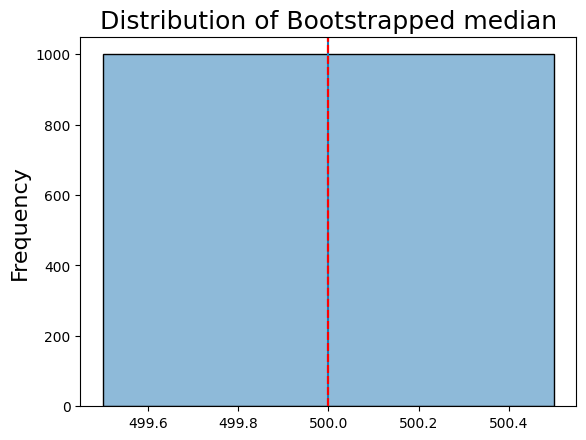

In [31]:
df_clean = df_clean.dropna(subset=['Citation Amount'])
population_n = len(df_clean)
sample_size = int(population_n * 0.10)

# 2. On tire l'échantillon de départ (Une seule fois !)
np.random.seed(42)
initial_sample = np.random.choice(df_clean['Citation Amount'], size=sample_size, replace=False)
n_bootstrap = 1000

bootstrap_median = []
for b in range(n_bootstrap):
    bootstrap_median.append(np.median(np.random.choice(initial_sample, size=sample_size, replace=True)))
bootstrap_median = np.array(bootstrap_median)

sns.histplot(bootstrap_median, kde=True, label='Bootstrap')
plt.axvline(x=np.median(bootstrap_median), ymin=0, ymax=1, linestyle='-')
plt.title('Distribution of Bootstrapped median', fontsize=18)
plt.ylabel('Frequency', fontsize=16)
lower_bound = np.percentile(bootstrap_median, 2.5)
upper_bound = np.percentile(bootstrap_median, 97.5)

plt.axvline(x=lower_bound, ymin=0, ymax=1, color='red', linestyle='--')
plt.axvline(x=upper_bound, ymin=0, ymax=1, color='red', linestyle='--')
print(f'Bootstrapped median: {np.median(bootstrap_median):.3}')
print(f'95% Confidence Intervals: [{lower_bound:.3}, {upper_bound:.3}]')

# **Conclusion And Future Study**

Regarding the core of my analysis, and following the initial data cleaning, I encountered a formatting issue with the temporal data. I had to apply the pd.to_datetime function to convert the entries, as Python was incorrectly interpreting the date variable as a generic 'object' rather than a datetime format. I identified this discrepancy by auditing the dataset's metadata, where I noticed that variables intended for numerical or chronological analysis were misclassified. This challenge underscores the critical importance of rigorous data preprocessing.

From a statistical standpoint, my analysis revealed a negative correlation within the dataset. Furthermore, the median was remarkably dominant—so much so that the 95% confidence interval was identical to the median itself (512, 512). This 'degenerate' interval indicates that a massive proportion of the fines are set at the exact same value of $512.00, demonstrating an exceptionally strong central tendency.

If given the opportunity to extend this research, I would like to perform a comparative analysis across different infraction categories. By examining the specific indices and types of violations, I could identify which factors contribute to such uniform pricing patterns or, conversely, detect any irregular outliers. This would provide a deeper understanding of the legislative or systemic factors that result in these consistent fine amounts."